## Initialising Edges, tweets, users metadata Files 

### Importing Libaries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.parquet as pq
import seaborn as sns
import gc

from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, FastRGCNConv
from torch_geometric.data import HeteroData, Data
from torch_geometric.loader import NeighborLoader

from sklearn.metrics import (
    roc_curve,
    auc,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    precision_recall_curve
)
from sklearn.ensemble import HistGradientBoostingClassifier

## Final Dataset Before Graph Conversion

This section prepares the final user–user interaction dataset before converting it into a graph learning format.

The raw data contains multiple entity types, including users, tweets, lists, and hashtags. To make the data suitable for graph learning, this section transforms the original edge table into a unified multi-relational user–user edge list, where each directed edge represents a specific interaction between two users. These interactions include follow, like, mention, reply, retweet, quote, community-based relations, and usage of the same  hasthtags.

Rather than using the raw heterogeneous edge table directly, this implementation first resolves intermediate entities such as tweets and lists so that all final edges are expressed consistently as **user → relation → user**.

Pipeline:
1. Read and load the raw edge table, user metadata, list data, and hashtag data.
2. Standardise identifiers and split the raw edges by relation type.
3. Build a `tweet_to_user` mapping so tweet-level interactions can be traced back to the corresponding author.
4. Convert each interaction type into a user–user relation, including follows, likes, mentions, replies, retweets, quotes, community-based links and usage of the same hashtag.
5. Combine all relation-specific edge tables into one final `df_user_user_edges_all` dataset and filter the final edge list to retain only edges where atleast one endpoints belong to the 40k labelled user set.
6. Produce summary statistics and connectivity checks to validate the final dataset before graph conversion.

### Reading Files

In [2]:
pf = pq.ParquetFile("./datasets/final_outputs/df_user_meta_full.parquet")
nested_cols = {
    f.name for f in pf.schema_arrow
    if pa.types.is_list(f.type) or pa.types.is_struct(f.type)
}
print("Skipping nested columns:", nested_cols)

flat_cols = [f.name for f in pf.schema_arrow if f.name not in nested_cols]
df_user = pq.read_table("./datasets/final_outputs/df_user_meta_full.parquet", columns=flat_cols).to_pandas()

df_edges = pq.read_table("./datasets/final_outputs/df_edges_final.parquet").to_pandas(
    ignore_metadata=True
)

Skipping nested columns: set()


### Display Rows

In [3]:
display(df_edges.head())

,source_id,target_id,relation
0,u972651,t1452809453233840128,post
1,u26555611,t509912809476722688,post
2,u99581347,t1470302937742258176,post
3,u12,t1418288863710171139,post
4,u595400360,t1224166717032751105,post


In [4]:
display(df_user.head())

,id,label,split,participation_degree,pinned_tweet_id,protected,verified,followers_count,following_count,tweet_count,...,avg_retweets_per_tweet,avg_replies_per_tweet,avg_quotes_per_tweet,engagement_rate,pct_allow_reply,fc_reply,num_unique_langs,pct_geo_tweets,has_reply_inconsistency,reply_inconsistency_count
0,u2664730894,human,train,1726,NaN,0,0,123,1090,1823,...,2735.176176,0.088088,0.003003,2735.506507,0.001001,88.00,16.0,0.0,1.0,5.0
1,u1679822588,bot,train,1127,1.143808e+18,0,0,238254,293,1400,...,278.911558,16.394975,0.869347,600.325628,0.000000,0.00,11.0,0.0,1.0,4.0
2,u2465283662,bot,test,3346,NaN,0,0,45541,1206,9194,...,93.491918,0.607759,1.496228,202.609914,0.001078,564.00,15.0,0.0,1.0,54.0
3,u1467973039883182090,human,train,1207,NaN,0,0,1573,1688,146,...,0.980435,0.939130,0.008696,5.273913,0.010870,86.40,4.0,0.0,1.0,89.0
4,u234059290,human,train,2267,1.470252e+18,0,0,4694,4739,91381,...,526.345060,0.334581,0.020958,529.062126,0.008982,37.25,9.0,0.0,1.0,164.0


## Spliting the raw edges by interaction by relation type

In [ ]:
df_edges = df_edges.copy()
df_user = df_user.copy()
valid_users = set(df_user["id"])

df_following_base   = df_edges[df_edges["relation"] == "following"].copy()
df_follower_base    = df_edges[df_edges["relation"] == "followed"].copy()
df_post_base        = df_edges[df_edges["relation"] == "post"].copy()
df_like_base        = df_edges[df_edges["relation"] == "like"].copy()
df_own_base         = df_edges[df_edges["relation"] == "own"].copy()
df_contain_base     = df_edges[df_edges["relation"] == "contain"].copy()
df_mentions_base    = df_edges[df_edges["relation"] == "mentioned"].copy()
df_replies_base     = df_edges[df_edges["relation"] == "replied_to"].copy()
df_retweets_base    = df_edges[df_edges["relation"] == "retweeted"].copy()
df_quotes_base      = df_edges[df_edges["relation"] == "quoted"].copy()
df_pinned_base      = df_edges[df_edges["relation"] == "pinned"].copy()
df_membership_base  = df_edges[df_edges["relation"] == "membership"].copy()
df_discuss_base     = df_edges[df_edges["relation"] == "discuss"].copy()

print("following:",     df_following_base.shape)
print("follower:",      df_follower_base.shape)
print("post:",          df_post_base.shape)
print("like:",          df_like_base.shape)
print("own:",           df_own_base.shape)
print("contain:",       df_contain_base.shape)
print("mentions:",      df_mentions_base.shape)
print("replies_to:",    df_replies_base.shape)
print("retweets:",      df_retweets_base.shape)
print("quotes:",        df_quotes_base.shape)
print("pinned:",        df_pinned_base.shape)
print("membership:",    df_membership_base.shape)
print("discuss:",       df_discuss_base.shape)


following: (313570, 3)
follower: (34676, 3)
post: (9437233, 3)
like: (299090, 3)
own: (4531, 3)
contain: (1758261, 3)
mentions: (1043855, 3)
replies_to: (672569, 3)
retweets: (1000974, 3)
quotes: (184452, 3)
pinned: (16842, 3)
membership: (130134, 3)
discuss: (7590118, 3)


## Build mapping from "user -> tweet -> user" for easy authorship retrieval

In [6]:
tweet_to_user = (
    df_post_base[["source_id", "target_id"]]
    .drop_duplicates()
    .rename(columns={"source_id": "author_user_id", "target_id": "tweet_id"})
)

tweet_to_user["author_user_id"] = tweet_to_user["author_user_id"].astype(str)
tweet_to_user["tweet_id"] = tweet_to_user["tweet_id"].astype(str)

tweet_to_user_map = dict(zip(tweet_to_user["tweet_id"], tweet_to_user["author_user_id"]))

print("tweet_to_user from post edges:", len(tweet_to_user_map))
tweet_to_user.head()

tweet_to_user from post edges: 9437233


,author_user_id,tweet_id
0,u972651,t1452809453233840128
1,u26555611,t509912809476722688
2,u99581347,t1470302937742258176
3,u12,t1418288863710171139
4,u595400360,t1224166717032751105


## Converting each interaction type into a user-user relation
### 1) user -> follows -> user

In [7]:
df_followers_flipped = (
    df_follower_base[["source_id", "target_id"]]
    .rename(columns={"source_id": "target_id", "target_id": "source_id"})
    [["source_id", "target_id"]]
    .copy()
)

df_following_all = pd.concat([
    df_following_base[["source_id", "target_id"]].copy(),
    df_followers_flipped
], ignore_index=True)

df_following_all["source_id"] = df_following_all["source_id"].astype(str)
df_following_all["target_id"] = df_following_all["target_id"].astype(str)
df_following_all["relation"] = "following"

df_follows = df_following_all[
    df_following_all["source_id"] != df_following_all["target_id"]
][["source_id", "target_id", "relation"]].drop_duplicates()

print(df_follows.shape)
df_follows.head()

(348246, 3)


,source_id,target_id,relation
0,u1483653523753476098,u50669520,following
1,u922617394379591680,u1329262027,following
2,u4833056519,u4416456732,following
3,u19264383,u1245260977626587136,following
4,u40156330,u379629857,following


### 2) user -> likes -> user

In [8]:
df_likes_user = (
    df_like_base[["source_id", "target_id"]]
    .rename(columns={"source_id": "source_id", "target_id": "tweet_id"})
    .assign(target_id=lambda x: x["tweet_id"].astype(str).map(tweet_to_user_map))
    .dropna(subset=["target_id"])
)
df_likes_user["relation"] = "likes"

df_likes_user = df_likes_user[
    df_likes_user["source_id"] != df_likes_user["target_id"]
][["source_id", "target_id", "relation"]].drop_duplicates()

print(df_likes_user.shape)
df_likes_user.head()

(33338, 3)


,source_id,target_id,relation
106426,u857722144809246722,u85605334,likes
106428,u97046557,u1328704176772288513,likes
106437,u287156977,u887606425479856128,likes
106438,u1100662343292248064,u75246346,likes
106443,u1223298266,u177101260,likes


### 3) user -> owner_of_communities_frequent_by -> user

In [ ]:
df_own_links = df_own_base[["source_id", "target_id"]].copy()
df_own_links.columns = ["owner_user_id", "list_id"]

df_contain_links = df_contain_base[["source_id", "target_id"]].copy()
df_contain_links.columns = ["list_id", "tweet_id"]

df_post_links = df_post_base[["source_id", "target_id"]].copy()
df_post_links.columns = ["author_user_id", "tweet_id"]

df_list_owner_to_user = (
    df_own_links
    .merge(df_contain_links, on="list_id", how="inner")
    .merge(df_post_links, on="tweet_id", how="inner")
)

df_list_owner_to_user = df_list_owner_to_user[
    (df_list_owner_to_user["owner_user_id"] != df_list_owner_to_user["author_user_id"])
].copy()

df_list_owner_to_user = df_list_owner_to_user.rename(columns={
    "owner_user_id": "source_id",
    "author_user_id": "target_id"
})[["source_id", "target_id"]]

df_list_owner_to_user["relation"] = "owner_of_communities_frequent_by"
df_list_owner_to_user = df_list_owner_to_user.drop_duplicates()

print(df_list_owner_to_user.shape)
df_list_owner_to_user.head()

(8143, 3)


,source_id,target_id,relation
0,u1716121,u661403,owner_of_communities_frequent_by
1,u1716121,u16817883,owner_of_communities_frequent_by
8,u1716121,u21017622,owner_of_communities_frequent_by
15,u1716121,u19767193,owner_of_communities_frequent_by
47,u79543,u9973392,owner_of_communities_frequent_by


### 4) user -> mentions -> user

In [10]:
df_mentions_user = df_mentions_base[["source_id", "target_id"]].copy()
df_mentions_user = df_mentions_user.rename(columns={"source_id": "mentioning_tweet_id"})

df_mentions_user["source_id"] = df_mentions_user["mentioning_tweet_id"].map(tweet_to_user_map)
df_mentions_user["relation"] = "mentions"

df_mentions_user = df_mentions_user[
    df_mentions_user["source_id"].notna() &
    (df_mentions_user["source_id"] != df_mentions_user["target_id"])
][["source_id", "target_id", "relation"]].drop_duplicates()

print(df_mentions_user.shape)
df_mentions_user.head()

(166963, 3)


,source_id,target_id,relation
12368,u3262723722,u3270678680,mentions
12370,u1184076585344884738,u41707730,mentions
12371,u340037000,u2949781365,mentions
12372,u15143478,u1247375072,mentions
12373,u124810572,u115091858,mentions


### 5) user -> replies_to -> user

In [11]:
df_replies_user = df_replies_base[["source_id", "target_id"]].copy()
df_replies_user = df_replies_user.rename(columns={
    "source_id": "reply_tweet_id",
    "target_id": "replied_to_tweet_id"
})

df_replies_user["source_id"] = df_replies_user["reply_tweet_id"].map(tweet_to_user_map)
df_replies_user["target_id"] = df_replies_user["replied_to_tweet_id"].map(tweet_to_user_map)
df_replies_user["relation"] = "replies_to"

df_replies_user = df_replies_user[
    df_replies_user["source_id"].notna() &
    df_replies_user["target_id"].notna() &
    (df_replies_user["source_id"] != df_replies_user["target_id"])
][["source_id", "target_id", "relation"]].drop_duplicates()

print(df_replies_user.shape)
df_replies_user.head()

(33385, 3)


,source_id,target_id,relation
175194,u2817674196,u11383092,replies_to
175237,u595982444,u14700783,replies_to
175292,u16659187,u2729061,replies_to
175295,u1126508332104192000,u752487999800094720,replies_to
175310,u325652049,u14230524,replies_to


### 6) user -> retweets -> user

In [12]:
df_retweets_user = df_retweets_base[["source_id", "target_id"]].copy()
df_retweets_user = df_retweets_user.rename(columns={
    "source_id": "retweet_tweet_id",
    "target_id": "retweeted_tweet_id"
})

df_retweets_user["source_id"] = df_retweets_user["retweet_tweet_id"].map(tweet_to_user_map)
df_retweets_user["target_id"] = df_retweets_user["retweeted_tweet_id"].map(tweet_to_user_map)
df_retweets_user["relation"] = "retweets"

df_retweets_user = df_retweets_user[
    df_retweets_user["source_id"].notna() &
    df_retweets_user["target_id"].notna() &
    (df_retweets_user["source_id"] != df_retweets_user["target_id"])
][["source_id", "target_id", "relation"]].drop_duplicates()

print(df_retweets_user.shape)
df_retweets_user.head()

(74644, 3)


,source_id,target_id,relation
175192,u14344469,u26703365,retweets
175197,u59303321,u1321131526809997313,retweets
175202,u547871798,u103989154,retweets
175205,u19782081,u15492359,retweets
175210,u35410744,u1204445607978569729,retweets


### 7) user -> quotes -> user

In [13]:
df_quotes_user = df_quotes_base[["source_id", "target_id"]].copy()
df_quotes_user = df_quotes_user.rename(columns={
    "source_id": "quote_tweet_id",
    "target_id": "quoted_tweet_id"
})

df_quotes_user["source_id"] = df_quotes_user["quote_tweet_id"].map(tweet_to_user_map)
df_quotes_user["target_id"] = df_quotes_user["quoted_tweet_id"].map(tweet_to_user_map)
df_quotes_user["relation"] = "quotes"

df_quotes_user = df_quotes_user[
    df_quotes_user["source_id"].notna() &
    df_quotes_user["target_id"].notna() &
    (df_quotes_user["source_id"] != df_quotes_user["target_id"])
][["source_id", "target_id", "relation"]].drop_duplicates()

print(df_quotes_user.shape)
df_quotes_user.head()

(21958, 3)


,source_id,target_id,relation
175236,u14278978,u1605,quotes
175533,u24080232,u759251,quotes
175562,u16432203,u732141019114930176,quotes
175584,u3225530490,u800459756292882432,quotes
175629,u3634881197,u1057823151692898307,quotes


### 8) user -> member_of_communities_owned_by -> user

In [14]:
df_membership_to_owner = (
    df_membership_base[["source_id", "target_id"]]
    .rename(columns={"source_id": "list_id", "target_id": "source_id"})
    .merge(
        df_own_base[["source_id", "target_id"]]
        .rename(columns={"source_id": "target_id", "target_id": "list_id"}),
        on="list_id",
        how="inner"
    )
    .copy()
)

df_membership_to_owner["relation"] = "member_of_communities_owned_by"

df_membership_to_owner = df_membership_to_owner[
    df_membership_to_owner["source_id"] != df_membership_to_owner["target_id"]
][["source_id", "target_id", "relation"]].drop_duplicates()

print(df_membership_to_owner.shape)
df_membership_to_owner.head()

(22069, 3)


,source_id,target_id,relation
0,u21457289,u1713417312,member_of_communities_owned_by
1,u1034844617261248512,u110065618,member_of_communities_owned_by
2,u14800270,u26054240,member_of_communities_owned_by
3,u47336791,u595982444,member_of_communities_owned_by
4,u14085099,u297124473,member_of_communities_owned_by


### 9) user -> discusses_same_topics -> user

In [ ]:
df_discuss_user = df_discuss_base[["source_id", "target_id"]].copy()
df_discuss_user["source_id"] = (
    df_discuss_user["source_id"]
    .astype(str)
    .map(tweet_to_user_map)
)

df_discuss_user = df_discuss_user.dropna(subset=["source_id", "target_id"]).drop_duplicates()

import duckdb
con = duckdb.connect()
con.execute("PRAGMA threads=12")
con.execute("SET memory_limit='6GB'")
con.execute("SET temp_directory='./.duckdb_tmp'")

con.register("discuss", df_discuss_user[["source_id", "target_id"]])

df_topics_user = con.execute("""
    WITH d AS (SELECT DISTINCT source_id, target_id FROM discuss),
    pairs AS (
        SELECT DISTINCT a.source_id AS u1, b.source_id AS u2
        FROM d a JOIN d b
          ON a.target_id = b.target_id
         AND a.source_id < b.source_id
    )
    SELECT u1 AS source_id, u2 AS target_id FROM pairs
    UNION
    SELECT u2 AS source_id, u1 AS target_id FROM pairs
""").df()
con.unregister("discuss")

df_topics_user["relation"] = "discuss_same_topic"
print(f"Pairs generated: {len(df_topics_user):,}")

print(df_topics_user.shape)
df_topics_user.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Pairs generated: 134,170,820
(134170820, 3)


,source_id,target_id,relation
0,u229665860,u162063442,discuss_same_topic
1,u5383942,u4280998754,discuss_same_topic
2,u3180827089,u2714874608,discuss_same_topic
3,u1260326985907212290,u1156107855621025792,discuss_same_topic
4,u4415413479,u1662010537,discuss_same_topic


### Combining all edge df into one final df and ensuring all edges are one-hop away (either source or target are part of 40k labelled user set)

In [16]:
df_user_user_edges_all = pd.concat([
    df_follows,
    df_likes_user,
    df_list_owner_to_user,
    df_mentions_user,
    df_replies_user,
    df_retweets_user,
    df_quotes_user,
    df_membership_to_owner,
    df_topics_user
], ignore_index=True)

print(df_user_user_edges_all.shape)
print(df_user_user_edges_all["relation"].value_counts())

(134879566, 3)
relation
discuss_same_topic                  134170820
following                              348246
mentions                               166963
retweets                                74644
replies_to                              33385
likes                                   33338
member_of_communities_owned_by          22069
quotes                                  21958
owner_of_communities_frequent_by         8143
Name: count, dtype: int64


In [ ]:
for _name in ["df_follows", "df_likes_user", "df_list_owner_to_user",
              "df_mentions_user", "df_replies_user", "df_retweets_user",
              "df_quotes_user", "df_membership_to_owner", "df_topics_user",
              "df_topics_user_rev", "df_discuss_user", "df_discuss_base"]:
    globals().pop(_name, None)
gc.collect()

60

In [18]:
users_40k_ids = set(df_user["id"])

df_user_user_edges_all = df_user_user_edges_all[
    df_user_user_edges_all["source_id"].isin(users_40k_ids) |
    df_user_user_edges_all["target_id"].isin(users_40k_ids)
]

In [19]:
df_user_user_edges_all

,source_id,target_id,relation
0,u1483653523753476098,u50669520,following
1,u922617394379591680,u1329262027,following
2,u4833056519,u4416456732,following
3,u19264383,u1245260977626587136,following
4,u40156330,u379629857,following
...,...,...,...
134879561,u106364904,u3296685517,discuss_same_topic
134879562,u20392725,u2858773839,discuss_same_topic
134879563,u1356603448066793472,u21446659,discuss_same_topic
134879564,u4767193469,u938349814424539137,discuss_same_topic


## Summary Statistics and Connectivitiy Checks

In [ ]:
import numpy as np
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

codes, uniques = pd.factorize(
    pd.concat([df_user_user_edges_all["source_id"],
               df_user_user_edges_all["target_id"]], ignore_index=True),
    sort=False,
)
m = len(df_user_user_edges_all)
n = len(uniques)

adj = coo_matrix(
    (np.ones(m, dtype=np.int8), (codes[:m], codes[m:])), shape=(n, n)
)
n_comp, labels = connected_components(adj, directed=False)
sizes = np.bincount(labels)

user_ids = pd.Index(df_user["id"].astype(str))
in_largest = pd.Index(uniques[labels == int(sizes.argmax())])

print(f"nodes {n:,} | edges {m:,} | components {n_comp} | largest {sizes.max():,}")
print(f"40k users in largest: {len(user_ids.intersection(in_largest)):,}")
print(f"mean degree: {2 * m / n:,.0f}")

nodes 50,554 | edges 134,879,566 | components 18 | largest 50,497
40k users in largest: 38,568
mean degree: 5,336


### Check connectivity of user-user heterogenous graph by inps

In [ ]:
src = df_user_user_edges_all["source_id"].astype(str)
tgt = df_user_user_edges_all["target_id"].astype(str)

codes, uniques = pd.factorize(pd.concat([src, tgt], ignore_index=True), sort=False)
m = len(src)
s_code = codes[:m].copy()
t_code = codes[m:].copy()
n = len(uniques)
del src, tgt, codes

adj = coo_matrix((np.ones(m, dtype=np.int8), (s_code, t_code)), shape=(n, n))
n_comp, labels = connected_components(adj, directed=False)
sizes = np.bincount(labels)

print(f"Total nodes in graph: {n:,}")
print(f"Total edges in graph: {m:,}")
print(f"\nNumber of connected components: {n_comp}")
print(f"Largest component size: {sizes.max():,}")
print(f"Smallest component size: {sizes.min():,}")

user_40k_ids = pd.Index(df_user["id"].astype(str).unique())
largest_label = int(sizes.argmax())
in_largest = pd.Index(uniques[labels == largest_label])
users_in_largest = user_40k_ids.intersection(in_largest)

print(f"\n40k users in largest component: {len(users_in_largest):,}")
print(f"40k users isolated: {len(user_40k_ids) - len(users_in_largest):,}")

print(f"\nMean degree: {2 * m / n:,.0f}")

Total nodes in graph: 50,554
Total edges in graph: 134,879,566

Number of connected components: 18
Largest component size: 50,497
Smallest component size: 2

40k users in largest component: 38,568
40k users isolated: 1,432

Mean degree: 5,336


## Graph Neural Networks

This section implements the final graph learning pipeline for Twitter bot detection.

The graph is **multi-relational**: each user is a node, and each directed edge captures a specific interaction type between users, such as follow, like, reply, retweet, quote, or discussing the same topic. Rather than collapsing all edge types into a single homogeneous graph, this implementation preserves relation identity through an `edge_type` tensor.

Pipeline:
1. Build a relation-aware graph from the final edge table.
2. Construct node feature and label tensors from user metadata.
3. Create a PyTorch Geometric `Data` object with `edge_index`, `edge_type`, and `edge_weight`.
4. Split labeled nodes into train, validation, and test sets.
5. Train a **mini-batch sampled R-GCN** using relation-aware message passing.
6. Evaluate the model with classification metrics and a confusion matrix.

### Import Libraries

In [24]:
print(torch.__version__, torch.version.cuda)
print(torch.cuda.get_arch_list())

2.11.0+cu128 12.8
['sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


### Edge building Cell

In [ ]:
df_edges = df_user_user_edges_all[["source_id", "target_id", "relation"]]

_combined = pd.concat([
    df_user["id"].astype(str),
    df_edges["source_id"].astype(str),
    df_edges["target_id"].astype(str),
], ignore_index=True)

codes, all_users = pd.factorize(_combined, sort=False)
all_users = pd.Index(all_users)

n_users = len(df_user)
n_edges = len(df_edges)

df_edges = pd.DataFrame({
    "source_idx": codes[n_users:n_users + n_edges].astype(np.int32),
    "target_idx": codes[n_users + n_edges:].astype(np.int32),
    "relation": df_user_user_edges_all["relation"].astype("category").to_numpy(),
})

del _combined, codes
gc.collect()

user_to_idx = {user_id: idx for idx, user_id in enumerate(all_users)}

relation_to_idx = {
    rel: idx for idx, rel in enumerate(sorted(df_edges["relation"].unique()))
}
df_edges["edge_type"] = df_edges["relation"].map(relation_to_idx)

edge_index = torch.tensor(
    df_edges[["source_idx", "target_idx"]].to_numpy(),
    dtype=torch.long
).t().contiguous()

edge_type = torch.tensor(
    df_edges["edge_type"].to_numpy(),
    dtype=torch.long
)

print("Number of nodes:", len(all_users))
print("Number of edges:", edge_index.size(1))
print("Relations:", relation_to_idx)

Number of nodes: 51967
Number of edges: 134879566
Relations: {'discuss_same_topic': 0, 'following': 1, 'likes': 2, 'member_of_communities_owned_by': 3, 'mentions': 4, 'owner_of_communities_frequent_by': 5, 'quotes': 6, 'replies_to': 7, 'retweets': 8}


### Generate feature and label tensors
Each user node is initialized with metadata-derived features and a binary bot label.

In the current setup, user metadata is used as the **initial node representation** `x`. These node features are then propagated through the graph during relation-aware message passing. The labels are stored separately in `y` for supervised training.

In [ ]:
label_col = "label"

feature_cols = df_user.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in feature_cols if col != label_col]

feature_cols = [c for c in feature_cols if not c.startswith("desc_tfidf_")]
print("features after dropping tfidf:", len(feature_cols))

df_nodes = pd.DataFrame({"user_id": all_users.astype(str)})

df_user_copy = df_user.copy()
df_user_copy["id"] = df_user_copy["id"].astype(str)

df_nodes = df_nodes.merge(
    df_user_copy[["id"] + feature_cols + [label_col]],
    left_on="user_id",
    right_on="id",
    how="left"
)

df_nodes[feature_cols] = df_nodes[feature_cols].fillna(0)

df_nodes[label_col] = (
    df_nodes[label_col].astype("object").map({"human": 0, "bot": 1})
)

df_nodes[label_col] = df_nodes[label_col].fillna(-1).astype(np.int64)
labeled_mask = df_nodes[label_col] != -1

print("label counts:", df_nodes[label_col].value_counts().to_dict())
print(f"labelled nodes: {labeled_mask.sum():,} of {len(df_nodes):,}")

node_features_tensor = torch.tensor(
    df_nodes[feature_cols].to_numpy(dtype=np.float32),
    dtype=torch.float
)

has_metadata = torch.tensor(
    df_nodes["id"].notna().to_numpy(dtype=np.float32)
).unsqueeze(1)

node_features_tensor = torch.cat([node_features_tensor, has_metadata], dim=1)
print("feature dim after flag:", node_features_tensor.size(1))

label_tensor = torch.tensor(
    df_nodes[label_col].to_numpy(dtype=np.int64),
    dtype=torch.long
)

features after dropping tfidf: 86
label counts: {0: 24400, 1: 15600, -1: 11967}
labelled nodes: 40,000 of 51,967
feature dim after flag: 87


In [27]:
print("total features:", node_features_tensor.size(1))
tfidf_cols = [c for c in feature_cols if c.startswith("desc_tfidf_")]
print("tfidf features:", len(tfidf_cols))
print("non-tfidf features:", node_features_tensor.size(1) - len(tfidf_cols))

total features: 87
tfidf features: 0
non-tfidf features: 87


### Create train, validation, and test masks

We use a custom stratified split so that the train, validation, and test sets preserve the class balance of the labeled users as closely as possible.

- **Train mask**: used to optimize model parameters
- **Validation mask**: used for model selection and early stopping
- **Test mask**: used only for final evaluation

In [ ]:
data = Data(
    x=node_features_tensor.float(),
    y=label_tensor.long(),
    edge_index=edge_index,
    edge_type=edge_type
)

data.labeled_mask = torch.tensor(labeled_mask.to_numpy(), dtype=torch.bool)

split_series = (
    df_nodes[["user_id"]]
    .merge(df_user_copy[["id", "model_split"]], left_on="user_id", right_on="id", how="left")
    ["model_split"]
)

train_mask = torch.tensor((split_series == "train").to_numpy(), dtype=torch.bool)
val_mask   = torch.tensor((split_series == "val").to_numpy(), dtype=torch.bool)
test_mask  = torch.tensor((split_series == "test").to_numpy(), dtype=torch.bool)

train_mask &= data.labeled_mask
val_mask   &= data.labeled_mask
test_mask  &= data.labeled_mask

print("split value counts:", split_series.value_counts(dropna=False).to_dict())
for name, m in [("train", train_mask), ("val", val_mask), ("test", test_mask)]:
    lab = data.y[m]
    print(f"{name}: {int(m.sum()):,} nodes, bot rate {float((lab == 1).float().mean()):.3f}")

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

print(data)
print("Train nodes:", int(data.train_mask.sum()))
print("Val nodes:", int(data.val_mask.sum()))
print("Test nodes:", int(data.test_mask.sum()))

split value counts: {'train': 32000, nan: 11967, 'test': 4000, 'val': 4000}
train: 32,000 nodes, bot rate 0.390
val: 4,000 nodes, bot rate 0.390
test: 4,000 nodes, bot rate 0.390
Data(x=[51967, 87], edge_index=[2, 134879566], y=[51967], edge_type=[134879566], labeled_mask=[51967], train_mask=[51967], val_mask=[51967], test_mask=[51967])
Train nodes: 32000
Val nodes: 4000
Test nodes: 4000


In [ ]:
X = df_nodes[feature_cols].to_numpy(np.float32)
y = df_nodes[label_col].to_numpy()

tr = train_mask.numpy()
va = val_mask.numpy()
te = test_mask.numpy()

print(f"train {tr.sum():,} | val {va.sum():,} | test {te.sum():,} | features {X.shape[1]}")

clf = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.1,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
)
clf.fit(X[tr], y[tr])

for name, m in [("val", va), ("test", te)]:
    prob = clf.predict_proba(X[m])[:, 1]
    pred = (prob >= 0.5).astype(int)
    print(
        f"{name:5} | P {precision_score(y[m], pred):.4f} "
        f"| R {recall_score(y[m], pred):.4f} "
        f"| F1 {f1_score(y[m], pred):.4f} "
        f"| AUC {roc_auc_score(y[m], prob):.4f} "
        f"| PR-AUC {average_precision_score(y[m], prob):.4f} "
        f"| Brier {brier_score_loss(y[m], prob):.4f}"
    )

train 32,000 | val 4,000 | test 4,000 | features 86
val   | P 0.8023 | R 0.8532 | F1 0.8270 | AUC 0.9418 | PR-AUC 0.9117 | Brier 0.0947
test  | P 0.8277 | R 0.8622 | F1 0.8446 | AUC 0.9475 | PR-AUC 0.9191 | Brier 0.0896


In [31]:
for name, m in [("train", train_mask), ("val", val_mask), ("test", test_mask)]:
    lab = data.y[m]
    n = int(m.sum())
    print(f"{name}: {n:,} nodes | bot {int((lab==1).sum()):,} | human {int((lab==0).sum()):,} | bot rate {float((lab==1).float().mean()):.3f}")

train: 32,000 nodes | bot 12,480 | human 19,520 | bot rate 0.390
val: 4,000 nodes | bot 1,560 | human 2,440 | bot rate 0.390
test: 4,000 nodes | bot 1,560 | human 2,440 | bot rate 0.390


### Convert the homogeneous graph into a heterogeneous graph and create relation-balanced mini-batch loaders

This cell converts the original homogeneous `Data` object into a `HeteroData` object so that each relation type is stored separately. This is necessary because we want to apply **relation-balanced neighbor sampling**, where different edge types are sampled with different fanout budgets.

The process has two main steps:

1. **`to_hetero_user_graph(data, relation_to_idx)`**
   - Creates a single node type, `"user"`, containing node features, labels, and train/validation/test masks.
   - Splits the original `edge_index` by `edge_type` so that each relation is stored separately as  
     `("user", relation_name, "user")`.

2. **`hetero_batch_to_rgcn_batch(batch, relation_to_idx, device)`**
   - Converts each sampled heterogeneous mini-batch back into a homogeneous batch with:
     - `x`
     - `y`
     - `edge_index`
     - `edge_type`
   - This allows the sampled batch to be passed into the existing R-GCN model, which expects homogeneous relational input.

After constructing `hetero_data`, we define **per-relation neighbor sampling budgets** through `num_neighbors`. This ensures that rarer but informative relations such as `retweets` or `mentions` are not overwhelmed by more frequent relations during training. At this stage, edge weights are no longer incorporated in RGCN training, as RGCN model cannot directly take in edge weights. Edge multiplicity is also not considered, as the empirical results we found revealed that having edge multiplicity introduces more noise to model training.

Finally, `NeighborLoader` is used to create training, validation, and test mini-batch loaders based on these relation-specific fanouts.

In [ ]:
def to_hetero_user_graph(data, relation_to_idx):
    hetero_data = HeteroData()

    hetero_data["user"].x = data.x
    hetero_data["user"].y = data.y
    hetero_data["user"].train_mask = data.train_mask
    hetero_data["user"].val_mask = data.val_mask
    hetero_data["user"].test_mask = data.test_mask

    idx_to_relation = {v: k for k, v in relation_to_idx.items()}

    order = torch.argsort(data.edge_type)
    sorted_types = data.edge_type[order]
    sorted_index = data.edge_index[:, order]

    boundaries = torch.searchsorted(
        sorted_types,
        torch.arange(len(relation_to_idx) + 1, device=sorted_types.device)
    )

    for rel_idx, rel_name in idx_to_relation.items():
        start, end = int(boundaries[rel_idx]), int(boundaries[rel_idx + 1])
        hetero_data["user", rel_name, "user"].edge_index = (
            sorted_index[:, start:end].contiguous()
        )

    del order, sorted_types, sorted_index
    gc.collect()

    return hetero_data


def hetero_batch_to_rgcn_batch(batch, relation_to_idx, device=None):
    x = batch["user"].x
    y = batch["user"].y

    edge_indices = []
    edge_types = []

    for edge_type in batch.edge_types:
        _, rel_name, _ = edge_type
        rel_edge_index = batch[edge_type].edge_index

        if rel_edge_index.numel() == 0:
            continue

        rel_idx = relation_to_idx[rel_name]
        rel_type_tensor = torch.full(
            (rel_edge_index.size(1),),
            rel_idx,
            dtype=torch.long,
            device=rel_edge_index.device
        )

        edge_indices.append(rel_edge_index)
        edge_types.append(rel_type_tensor)

    if len(edge_indices) > 0:
        edge_index = torch.cat(edge_indices, dim=1)
        edge_type = torch.cat(edge_types, dim=0)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long, device=x.device)
        edge_type = torch.empty((0,), dtype=torch.long, device=x.device)

    out = Data(x=x, y=y, edge_index=edge_index, edge_type=edge_type)
    out.batch_size = batch["user"].batch_size

    if device is not None:
        out = out.to(device)

    return out

hetero_data = to_hetero_user_graph(data, relation_to_idx)

num_neighbors = {
    ("user", "discuss_same_topic", "user"): [2, 2],
    ("user", "following", "user"): [4, 2],
    ("user", "mentions", "user"): [4, 2],
    ("user", "retweets", "user"): [4, 2],
    ("user", "likes", "user"): [3, 1],
    ("user", "replies_to", "user"): [3, 1],
    ("user", "quotes", "user"): [3, 1],
    ("user", "member_of_communities_owned_by", "user"): [2, 1],
    ("user", "owner_of_communities_frequent_by", "user"): [2, 1],
}

train_loader = NeighborLoader(
    hetero_data,
    input_nodes=("user", hetero_data["user"].train_mask),
    num_neighbors=num_neighbors,
    batch_size=512,
    shuffle=True
)

val_loader = NeighborLoader(
    hetero_data,
    input_nodes=("user", hetero_data["user"].val_mask),
    num_neighbors=num_neighbors,
    batch_size=512,
    shuffle=False
)

test_loader = NeighborLoader(
    hetero_data,
    input_nodes=("user", hetero_data["user"].test_mask),
    num_neighbors=num_neighbors,
    batch_size=512,
    shuffle=False
)

### Build training, validation, and test utilities

The following helper functions implement:
- mini-batch training
- mini-batch validation
- early stopping based on validation loss
- final test evaluation

Because the graph is large, training is done with sampled neighborhoods rather than full-batch propagation over the entire graph.

### GNN Model

Some considerations: what sampling scheme? What aggregation method? What research backs up our choice?

This section implements a **mini-batch sampled relation-aware R-GCN**.

Rationale:
- The graph contains multiple edge types with different semantic meanings.
- `FastRGCNConv` allows the model to learn relation-specific transformations.
- Mini-batch neighborhood sampling makes training feasible on a large user graph.

Accordingly, we keep:
- `edge_type` to represent **what kind of relation** an edge encodes
- `edge_weight` only as an optional **strength within that relation**

#### Model choice: mini-batch sampled R-GCN

The final model is a **two-layer relation-aware graph neural network** built with `FastRGCNConv`.

Why this model is used here:
- it is designed for **multi-relational graphs**
- it preserves relation semantics directly through `edge_type`
- it scales better than full-batch relational GNN training when paired with neighborhood sampling
- it is more suitable than a homogeneous GraphSAGE baseline when the relation identity itself is informative

Compared with a standard GraphSAGE formulation, this design better matches the structure of the current Twitter bot graph, where the distinction between follow, retweet, reply, quote, mention, and topic relations is important.

- `Input Projection Layer with batch normalization projecting raw features into a 64-dimensional embedding space`
- `Two FastRGCNConv layers performing relation-aware message passing (64 → 32) with basis decomposition`
- `Residual connection between R-GCN layers to mitigate over-smoothing and improve gradient flow`
- `Batch normalization applied after each R-GCN layer`
- `LeakyReLU activation to prevent dying ReLU problem`
- `Dropout (0.2) for regularization`
- `Feed-forward classification head with two linear layers (32 → 16 → 2)`

### Define the mini-batch relational graph convolutional network

This cell defines the `MiniBatchBotRGCN` model used for user-level bot classification.

The architecture consists of:

- **Input projection layer**
  - Batch normalisation is first applied to the input node features.
  - A linear layer projects the raw input features into a hidden embedding space.

- **Two R-GCN layers**
  - Two `FastRGCNConv` layers perform **relation-aware message passing**.
  - Each layer aggregates neighbor information separately for each relation type using relation-specific transformations.
  - Basis decomposition (`num_bases`) is used to reduce parameter count and improve efficiency.

- **Activation and regularisation**
  - `LeakyReLU` is applied after each transformation.
  - `Dropout` is applied between layers to reduce overfitting.

- **Classification head**
  - A fully connected hidden layer further refines the representation.
  - A final linear layer outputs logits for the target classes.

In [ ]:
class MiniBatchBotRGCN(torch.nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, num_relations, num_bases=None, dropout=0.2):
        super().__init__()

        self.bn_in = nn.BatchNorm1d(num_features)
        self.lin_in = nn.Linear(num_features, hidden_dim)

        self.rgcn1 = FastRGCNConv(
            in_channels=hidden_dim,
            out_channels=hidden_dim,
            num_relations=num_relations,
            num_bases=num_bases
        )
        self.bn_rgcn1 = nn.BatchNorm1d(hidden_dim)

        self.rgcn2 = FastRGCNConv(
            in_channels=hidden_dim,
            out_channels=hidden_dim // 2,
            num_relations=num_relations,
            num_bases=num_bases
        )
        self.bn_rgcn2 = nn.BatchNorm1d(hidden_dim // 2)

        self.dropout = nn.Dropout(dropout)

        self.residual_proj = nn.Linear(hidden_dim, hidden_dim // 2)
        self.lin_hidden = nn.Linear(hidden_dim // 2, hidden_dim // 4)
        self.lin_out = nn.Linear(hidden_dim // 4, num_classes)   

    def forward(self, x, edge_index, edge_type):
        x = self.bn_in(x)
        x = F.leaky_relu(self.lin_in(x))

        h = self.rgcn1(x, edge_index, edge_type)
        h = self.bn_rgcn1(h)
        h = F.leaky_relu(h + x)
        h = self.dropout(h)

        out = self.rgcn2(h, edge_index, edge_type)
        out = self.bn_rgcn2(out)
        out = F.leaky_relu(out + self.residual_proj(h))
        out = self.dropout(out)

        out = F.leaky_relu(self.lin_hidden(out))
        out = self.dropout(out)
        out = self.lin_out(out)
        return out

### Initialise device, model, loss function, and optimiser

- **Number of output classes**
  - The number of classes is inferred from `label_tensor`.

- **Model initialisation**
  - The `MiniBatchBotRGCN` model is created with:
    - input dimension equal to the number of node features
    - hidden dimension of 64
    - output dimension equal to the number of classes
    - number of relations equal to the number of unique edge types
    - basis decomposition for parameter efficiency
    - dropout for regularisation

- **Loss function**
  - `CrossEntropyLoss` is used for multi-class classification over logits.

- **Optimiser**
  - Adam is used with a learning rate of 0.001 and weight decay of 0.05.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = int(label_tensor.max().item()) + 1

model = MiniBatchBotRGCN(
    num_features=node_features_tensor.size(1),
    hidden_dim=64,
    num_classes=num_classes,
    num_relations=len(relation_to_idx),
    num_bases=min(8, len(relation_to_idx)),
    dropout=0.4
).to(device)

train_y = data.y[data.train_mask]
counts = torch.bincount(train_y, minlength=num_classes).float()
class_weights = (counts.sum() / (num_classes * counts)).to(device)
print("class weights:", class_weights.tolist())

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-2)

print(device)

class weights: [0.8196721076965332, 1.2820513248443604]
cuda


### Train Function

In [37]:
def train_rgcn_minibatch(model, loader, criterion, optimizer, device, relation_to_idx):
    model.train()
    total_loss = 0.0
    total_examples = 0

    for hetero_batch in loader:
        batch = hetero_batch_to_rgcn_batch(hetero_batch, relation_to_idx, device)

        optimizer.zero_grad()

        out = model(batch.x, batch.edge_index, batch.edge_type)

        seed_count = batch.batch_size
        loss = criterion(out[:seed_count], batch.y[:seed_count])

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * seed_count
        total_examples += seed_count

    return total_loss / total_examples

### Evaluate Function

In [ ]:
@torch.no_grad()
def evaluate_rgcn_minibatch(model, loader, criterion, device, relation_to_idx):
    model.eval()

    total_loss = 0.0
    total_examples = 0

    all_true = []
    all_logits = []
    all_probs = []
    all_pred = []

    for hetero_batch in loader:
        batch = hetero_batch_to_rgcn_batch(hetero_batch, relation_to_idx, device)

        out = model(batch.x, batch.edge_index, batch.edge_type)

        seed_count = batch.batch_size
        logits = out[:seed_count]
        y_true = batch.y[:seed_count]

        loss = criterion(logits, y_true)

        probs = torch.softmax(logits, dim=1)
        pred = logits.argmax(dim=1)

        total_loss += loss.item() * seed_count
        total_examples += seed_count

        all_true.append(y_true.cpu())
        all_logits.append(logits.cpu())
        all_probs.append(probs.cpu())
        all_pred.append(pred.cpu())

    y_true = torch.cat(all_true).numpy()
    y_logits = torch.cat(all_logits).numpy()
    y_probs = torch.cat(all_probs).numpy()
    y_pred = torch.cat(all_pred).numpy()

    avg_loss = total_loss / total_examples

    metrics = {
        "loss": avg_loss,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    return y_true, y_logits, y_probs, y_pred, metrics

### Train and Validate Function

In [39]:
def train_validate_rgcn_minibatch(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    relation_to_idx,
    epoch=30,
    early_stopping_patience=10
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_precision": [],
        "val_recall": [],
        "val_accuracy": [],
        "val_f1": []
    }

    best_val_f1 = -1.0
    best_state = None
    patience_counter = 0

    for ep in range(epoch):
        train_loss = train_rgcn_minibatch(
            model, train_loader, criterion, optimizer, device, relation_to_idx
        )
        
        _, _, _, _, metrics = evaluate_rgcn_minibatch(
            model, val_loader, criterion, device, relation_to_idx)
        
        val_loss = metrics["loss"]
        precision = metrics["precision"]
        recall = metrics["recall"]
        accuracy = metrics["accuracy"]
        f1 = metrics["f1"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_precision"].append(precision)
        history["val_recall"].append(recall)
        history["val_accuracy"].append(accuracy)
        history["val_f1"].append(f1)

        print(
            f"Epoch {ep+1:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Precision: {precision:.4f} | "
            f"Recall: {recall:.4f} | "
            f"Accuracy: {accuracy:.4f} | "
            f"F1: {f1:.4f}"
        )

        if f1 > best_val_f1:
            best_val_f1 = f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= early_stopping_patience:
            print(f"Early stopping triggered at epoch {ep+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [40]:
history = train_validate_rgcn_minibatch(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    relation_to_idx=relation_to_idx,
    epoch=50
)

Epoch 001 | Train Loss: 0.5751 | Val Loss: 0.4081 | Precision: 0.7170 | Recall: 0.8641 | Accuracy: 0.8140 | F1: 0.7837
Epoch 002 | Train Loss: 0.4309 | Val Loss: 0.3679 | Precision: 0.7381 | Recall: 0.8853 | Accuracy: 0.8327 | F1: 0.8050
Epoch 003 | Train Loss: 0.3939 | Val Loss: 0.3528 | Precision: 0.7416 | Recall: 0.9071 | Accuracy: 0.8405 | F1: 0.8160
Epoch 004 | Train Loss: 0.3717 | Val Loss: 0.3395 | Precision: 0.7582 | Recall: 0.9026 | Accuracy: 0.8498 | F1: 0.8241
Epoch 005 | Train Loss: 0.3603 | Val Loss: 0.3340 | Precision: 0.7809 | Recall: 0.8865 | Accuracy: 0.8588 | F1: 0.8304
Epoch 006 | Train Loss: 0.3453 | Val Loss: 0.3225 | Precision: 0.7825 | Recall: 0.8994 | Accuracy: 0.8632 | F1: 0.8369
Epoch 007 | Train Loss: 0.3331 | Val Loss: 0.3143 | Precision: 0.7997 | Recall: 0.8981 | Accuracy: 0.8725 | F1: 0.8460
Epoch 008 | Train Loss: 0.3244 | Val Loss: 0.3078 | Precision: 0.7818 | Recall: 0.9096 | Accuracy: 0.8658 | F1: 0.8409
Epoch 009 | Train Loss: 0.3168 | Val Loss: 0.299

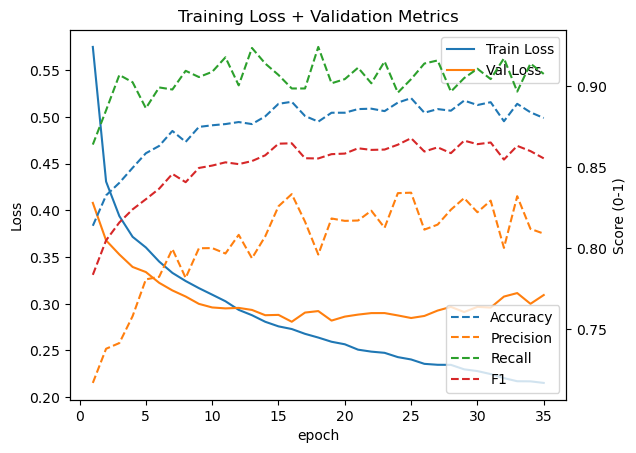

In [ ]:
df_history = pd.DataFrame(history)
df_history["epoch"] = range(1, len(df_history) + 1)

fig, ax1 = plt.subplots()

sns.lineplot(data=df_history, x="epoch", y="train_loss", ax=ax1, label="Train Loss")
sns.lineplot(data=df_history, x="epoch", y="val_loss", ax=ax1, label="Val Loss")
ax1.set_ylabel("Loss")

ax2 = ax1.twinx()
sns.lineplot(data=df_history, x="epoch", y="val_accuracy", ax=ax2, linestyle="--", label="Accuracy")
sns.lineplot(data=df_history, x="epoch", y="val_precision", ax=ax2, linestyle="--", label="Precision")
sns.lineplot(data=df_history, x="epoch", y="val_recall", ax=ax2, linestyle="--", label="Recall")
sns.lineplot(data=df_history, x="epoch", y="val_f1", ax=ax2, linestyle="--", label="F1")

ax2.set_ylabel("Score (0-1)")

plt.title("Training Loss + Validation Metrics")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1, loc="best")

plt.show()

### Test Function

In [42]:
@torch.no_grad()
def test_rgcn_minibatch(model, test_loader, criterion, device, relation_to_idx, show_cm=True):
    y_true, y_logits, y_probs, y_pred, metrics = evaluate_rgcn_minibatch(
        model, test_loader, criterion, device, relation_to_idx
    )

    print(f"Test Loss:  {metrics['loss']:.4f}")
    print(f"Precision:  {metrics['precision']:.4f}")
    print(f"Recall:     {metrics['recall']:.4f}")
    print(f"Accuracy:   {metrics['accuracy']:.4f}")
    print(f"F1 Score:   {metrics['f1']:.4f}")

    if show_cm:
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap="Blues")
        plt.title("Confusion Matrix")
        plt.show()

    return y_true, y_logits, y_probs, y_pred, metrics

Test Loss:  0.2807
Precision:  0.8432
Recall:     0.8891
Accuracy:   0.8922
F1 Score:   0.8655


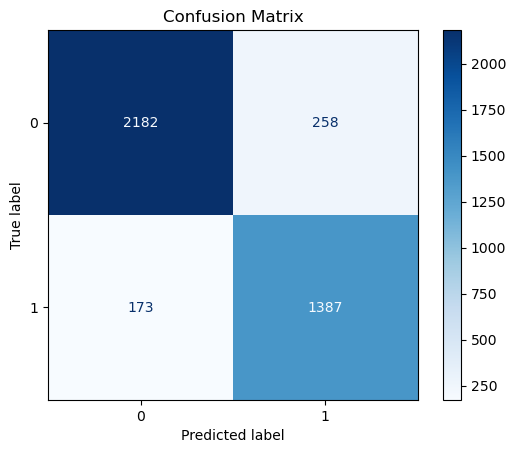

In [43]:
y_true, y_logits, y_probs, y_pred, metrics = test_rgcn_minibatch(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    relation_to_idx=relation_to_idx,
    show_cm=True
)

## Summary statistics
- Validate node count
- Validate edge count
- Validate edge_type count
- Confirm feature dimension
- Confirm split sizes
- Confirm number of relation types

In [44]:
num_nodes_from_mapping = len(user_to_idx)
num_nodes_from_x = data.x.shape[0]
num_labels = data.y.shape[0]
num_edges = data.edge_index.shape[1]
num_edge_types = data.edge_type.shape[0]
num_features = data.x.shape[1]

print("Summary Statistics for mini-batch R-GCN graph")
print(f"Nodes from user_to_idx:   {num_nodes_from_mapping:,}")
print(f"Nodes in data.x:          {num_nodes_from_x:,}")
print(f"Labels in data.y:         {num_labels:,}")
print(f"Edges in data.edge_index: {num_edges:,}")
print(f"Edge types:               {num_edge_types:,}")
print(f"Features per node:        {num_features:,}")
print(f"Relations retained:       {len(relation_to_idx):,}")

print("\nConsistency checks:")
print(f"x matches node mapping:    {num_nodes_from_x == num_nodes_from_mapping}")
print(f"y matches x:               {num_labels == num_nodes_from_x}")
print(f"edge_type matches edges:   {num_edge_types == num_edges}")

print("\nSplit sizes:")
print(f"Train nodes: {int(train_mask.sum()):,}")
print(f"Val nodes:   {int(val_mask.sum()):,}")
print(f"Test nodes:  {int(test_mask.sum()):,}")
print(f"Total split: {(int(train_mask.sum()) + int(val_mask.sum()) + int(test_mask.sum())):,}")

Summary Statistics for mini-batch R-GCN graph
Nodes from user_to_idx:   51,967
Nodes in data.x:          51,967
Labels in data.y:         51,967
Edges in data.edge_index: 134,879,566
Edge types:               134,879,566
Features per node:        87
Relations retained:       9

Consistency checks:
x matches node mapping:    True
y matches x:               True
edge_type matches edges:   True

Split sizes:
Train nodes: 32,000
Val nodes:   4,000
Test nodes:  4,000
Total split: 40,000


## Performance measures

### ROC Curve
A ROC curve can be added here to examine the trade-off between true positive rate and false positive rate across thresholds. This is especially useful when the decision threshold may later be tuned instead of fixed at the default argmax prediction.

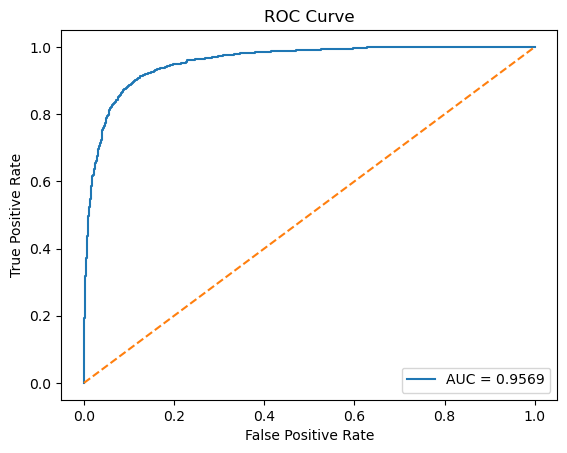

In [45]:
y_prob_bot = y_probs[:, 1]

fpr, tpr, thresholds = roc_curve(y_true, y_prob_bot)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Comments

The ROC curve demonstrates strong performance, with an AUC of 0.9396, indicating that the model is  effective at distinguishing between bot and human users. The curve rises steeply towards the top-left corner, showing that the model achieves a high true positive rate even at low false positive rates. This suggests that the model can correctly identify a large proportion of bots while maintaining relatively few false alarms.

### Precision-Recall Curve
A precision-recall curve is especially informative for imbalanced bot detection tasks because it focuses directly on the trade-off between retrieving bots and avoiding false positives.

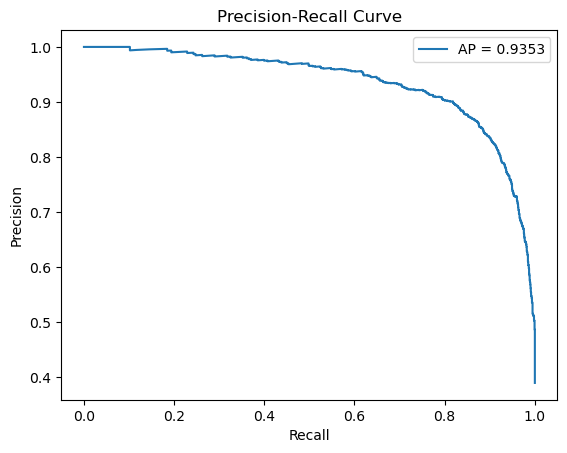

In [46]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, y_prob_bot)
ap_score = average_precision_score(y_true, y_prob_bot)

plt.figure()
plt.plot(recall_vals, precision_vals, label=f"AP = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

Comments

The Precision–Recall curve further confirms strong performance, with an Average Precision (AP) of 0.9238. Precision remains close to 1.0 across a wide range of recall values, indicating that the model maintains high accuracy in its positive predictions even as it retrieves more bot accounts.

However, as recall approaches 1.0, precision drops more. This reflects the  trade-off where capturing nearly all bots introduces more false positives. Despite this, the overall curve remains high, suggesting that the model performs well even under class imbalance.

### Get predictions and build evaluation table

In [ ]:
threshold = 0.5

y_prob_bot = y_probs[:, 1]

y_pred = (y_prob_bot >= threshold).astype(int)

test_node_idx = data.test_mask.nonzero(as_tuple=True)[0].cpu().numpy()
node_to_user = dict(enumerate(df_nodes["user_id"].astype(str)))

print("len(test_node_idx):", len(test_node_idx))
print("len(y_true):", len(y_true))
print("len(y_pred):", len(y_pred))
print("len(y_prob_bot):", len(y_prob_bot))

df_eval = pd.DataFrame({
    "node_idx": test_node_idx,
    "y_true": y_true,
    "y_pred": y_pred,
    "y_prob_bot": y_prob_bot
})

df_eval["error"] = df_eval["y_true"] != df_eval["y_pred"]
df_eval["error_type"] = np.select(
    [
        (df_eval["y_true"] == 0) & (df_eval["y_pred"] == 1),
        (df_eval["y_true"] == 1) & (df_eval["y_pred"] == 0),
        (df_eval["y_true"] == 1) & (df_eval["y_pred"] == 1),
        (df_eval["y_true"] == 0) & (df_eval["y_pred"] == 0),
    ],
    [
        "False Positive",
        "False Negative",
        "True Positive",
        "True Negative"
    ],
    default="Other"
)

df_eval["confidence"] = np.where(
    df_eval["y_pred"] == 1,
    df_eval["y_prob_bot"],
    1 - df_eval["y_prob_bot"]
)

df_eval["distance_from_0.5"] = np.abs(df_eval["y_prob_bot"] - 0.5)

df_eval["user_id"] = df_eval["node_idx"].map(node_to_user)

df_user_copy = df_user.copy()
df_user_copy["id"] = df_user_copy["id"].astype(str)

df_eval = df_eval.merge(
    df_user_copy,
    left_on="user_id",
    right_on="id",
    how="left"
)

df_errors = df_eval[df_eval["error"]].copy()

print("df_eval shape:", df_eval.shape)
print("df_errors shape:", df_errors.shape)
df_errors.head(10)

len(test_node_idx): 4000
len(y_true): 4000
len(y_pred): 4000
len(y_prob_bot): 4000
df_eval shape: (4000, 399)
df_errors shape: (431, 399)


,node_idx,y_true,y_pred,y_prob_bot,error,error_type,confidence,distance_from_0.5,user_id,id,...,avg_retweets_per_tweet,avg_replies_per_tweet,avg_quotes_per_tweet,engagement_rate,pct_allow_reply,fc_reply,num_unique_langs,pct_geo_tweets,has_reply_inconsistency,reply_inconsistency_count
0,2,1,0,0.055507,True,False Negative,0.944493,0.444493,u2465283662,u2465283662,...,93.491918,0.607759,1.496228,202.609914,0.001078,564.0,15.0,0.000000,1.0,54.0
5,43,1,0,0.001379,True,False Negative,0.998621,0.498621,u38669987,u38669987,...,3204.018482,0.044747,0.000973,3204.273346,0.000973,46.0,4.0,0.000000,1.0,20.0
15,188,1,0,0.109389,True,False Negative,0.890611,0.390611,u936331435614593024,u936331435614593024,...,142.571250,0.090000,0.023750,144.072500,0.000000,0.0,7.0,0.152500,1.0,16.0
16,210,0,1,0.643108,True,False Positive,0.643108,0.143108,u1341711996287242240,u1341711996287242240,...,262.807947,0.384106,0.026490,264.317881,0.000000,0.0,7.0,0.000000,1.0,5.0
17,220,1,0,0.004859,True,False Negative,0.995141,0.495141,u63815425,u63815425,...,142.486974,0.097194,0.036072,142.747495,0.000000,0.0,6.0,0.021042,1.0,217.0
19,233,0,1,0.757335,True,False Positive,0.757335,0.257335,u893897602575384576,u893897602575384576,...,29.200000,0.000000,0.000000,29.800000,0.000000,0.0,1.0,0.000000,0.0,0.0
26,281,1,0,0.484759,True,False Negative,0.515241,0.015241,u1280598815280676866,u1280598815280676866,...,782.000000,0.000000,0.000000,782.500000,0.000000,0.0,2.0,0.000000,0.0,0.0
27,283,1,0,0.001916,True,False Negative,0.998084,0.498084,u2603132052,u2603132052,...,36.130653,0.145729,0.020101,37.045226,0.000000,0.0,3.0,0.000000,1.0,3.0
28,285,0,1,0.623696,True,False Positive,0.623696,0.123696,u1073730367327215618,u1073730367327215618,...,4376.042553,0.042553,0.000000,4377.510638,0.000000,0.0,2.0,0.000000,1.0,20.0
29,288,0,1,0.589362,True,False Positive,0.589362,0.089362,u1380584522228506625,u1380584522228506625,...,190.720588,0.220588,0.000000,191.397059,0.014706,15.0,6.0,0.000000,0.0,0.0


### Core evaluation metrics

In [ ]:
y_prob_bot = y_probs[:, 1]

print("=" * 60)
print("TEST SET CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, digits=4))

print("=" * 60)
print("CORE PERFORMANCE METRICS")
print("=" * 60)
print(f"ROC-AUC:            {roc_auc_score(y_true, y_prob_bot):.4f}")
print(f"PR-AUC / AP:        {average_precision_score(y_true, y_prob_bot):.4f}")
print(f"Precision:          {precision_score(y_true, y_pred):.4f}")
print(f"Recall:             {recall_score(y_true, y_pred):.4f}")
print(f"F1 Score:           {f1_score(y_true, y_pred):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"Brier Score:        {brier_score_loss(y_true, y_prob_bot):.4f}")


print("=" * 60)
print("ERROR TYPE COUNTS")
print("=" * 60)
print(df_eval["error_type"].value_counts())

print("=" * 60)
print("CONFIDENCE SUMMARY BY ERROR TYPE")
print("=" * 60)
print(
    df_eval.groupby("error_type")[["confidence", "distance_from_0.5"]]
    .agg(["mean", "median", "min", "max", "count"])
    .round(4)
)

TEST SET CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9265    0.8943    0.9101      2440
           1     0.8432    0.8891    0.8655      1560

    accuracy                         0.8922      4000
   macro avg     0.8849    0.8917    0.8878      4000
weighted avg     0.8940    0.8922    0.8927      4000

CORE PERFORMANCE METRICS
ROC-AUC:            0.9569
PR-AUC / AP:        0.9353
Precision:          0.8432
Recall:             0.8891
F1 Score:           0.8655
Balanced Accuracy:  0.8917
Brier Score:        0.0791
ERROR TYPE COUNTS
error_type
True Negative     2182
True Positive     1387
False Positive     258
False Negative     173
Name: count, dtype: int64
CONFIDENCE SUMMARY BY ERROR TYPE
               confidence                               distance_from_0.5  \
                     mean  median     min     max count              mean   
error_type                                                                  
False Negative   

### Misclassified User Metadata Profiling

TOP 10 MOST OVERCONFIDENT MISTAKES


,user_id,y_true,y_pred,y_prob_bot,confidence,error_type
544,u937467860,1,0,0.000500,0.999500,False Negative
5,u38669987,1,0,0.001379,0.998621,False Negative
805,u19536280,1,0,0.001540,0.998460,False Negative
27,u2603132052,1,0,0.001916,0.998084,False Negative
3540,u1094550761135108096,0,1,0.998068,0.998068,False Positive
1444,u52163498,1,0,0.001963,0.998037,False Negative
3040,u510358755,1,0,0.002106,0.997894,False Negative
367,u28649627,1,0,0.002140,0.997860,False Negative
3258,u48611134,1,0,0.002233,0.997767,False Negative
2150,u82056281,1,0,0.004839,0.995161,False Negative


TOP 10 MOST AMBIGUOUS MISTAKES


,user_id,y_true,y_pred,y_prob_bot,distance_from_0.5,error_type
1725,u1102992281290694656,1,0,0.499569,0.000431,False Negative
1100,u1220876453077630976,0,1,0.501189,0.001189,False Positive
1910,u1275709288787345408,0,1,0.501848,0.001848,False Positive
1092,u987978757,0,1,0.502495,0.002495,False Positive
2898,u1124703427458732032,0,1,0.503698,0.003698,False Positive
3534,u732406602561507329,1,0,0.494845,0.005155,False Negative
2309,u4612661720,1,0,0.492849,0.007151,False Negative
418,u23872089,0,1,0.507818,0.007818,False Positive
1915,u1317162708748337154,0,1,0.508490,0.008490,False Positive
758,u257512113,0,1,0.508893,0.008893,False Positive


features after dropping tfidf: 85
Top differentiating features between FP and FN:
['followers_count', 'follower_following_disparity', 'posting_regularity', 'tweet_count', 'following_count', 'engagement_rate', 'account_age_days', 'avg_retweets_per_tweet', 'participation_degree', 'avg_likes_per_tweet']


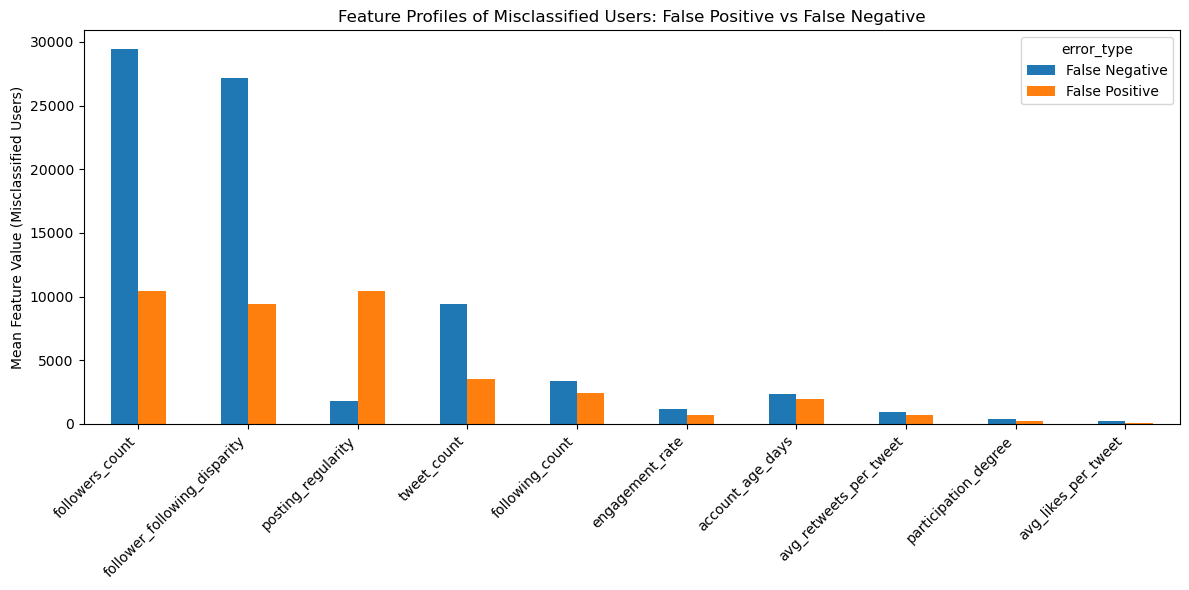

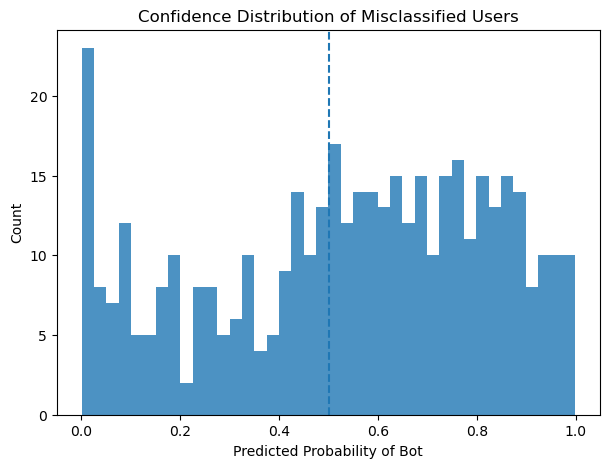

In [ ]:
print("=" * 60)
print("TOP 10 MOST OVERCONFIDENT MISTAKES")
print("=" * 60)
display(
    df_errors.sort_values("confidence", ascending=False).head(10)[
        ["user_id", "y_true", "y_pred", "y_prob_bot", "confidence", "error_type"]
    ]
)

print("=" * 60)
print("TOP 10 MOST AMBIGUOUS MISTAKES")
print("=" * 60)
display(
    df_errors.sort_values("distance_from_0.5", ascending=True).head(10)[
        ["user_id", "y_true", "y_pred", "y_prob_bot", "distance_from_0.5", "error_type"]
    ]
)

error_feature_cols = df_errors.select_dtypes(include=np.number).columns.tolist()

exclude_cols = {
    "node_idx", "y_true", "y_pred", "y_prob_bot", "error", "confidence", "distance_from_0.5"
}

feature_cols = [
    c for c in feature_cols
    if c not in exclude_cols
    and "id" not in c.lower()
    and not c.startswith("desc_tfidf")
]
print("features after dropping tfidf:", len(feature_cols))

df_fp = df_errors[df_errors["error_type"] == "False Positive"]
df_fn = df_errors[df_errors["error_type"] == "False Negative"]

valid_cols = [
    c for c in feature_cols
    if df_fp[c].notna().sum() > 0 and df_fn[c].notna().sum() > 0
]

mean_diff = (df_fp[valid_cols].mean() - df_fn[valid_cols].mean()).abs()
top_features = mean_diff.sort_values(ascending=False).head(10).index.tolist()

print("Top differentiating features between FP and FN:")
print(top_features)

summary = df_errors.groupby("error_type")[top_features].mean()

summary.T.plot(kind="bar", figsize=(12, 6))
plt.title("Feature Profiles of Misclassified Users: False Positive vs False Negative")
plt.ylabel("Mean Feature Value (Misclassified Users)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(df_errors["y_prob_bot"], bins=40, alpha=0.8)
plt.axvline(0.5, linestyle="--")
plt.xlabel("Predicted Probability of Bot")
plt.ylabel("Count")
plt.title("Confidence Distribution of Misclassified Users")
plt.show()

### Misclassified User In-degree, Out-degree, Edge Relation Type Profiling

GRAPH PROFILE SUMMARY FOR MISCLASSIFIED USERS


in_degree                          out_degree              \
                    mean  median min    max count       mean  median min   
error_type                                                                 
False Negative   4192.99  2760.0   1  20544   173    4207.79  2757.0   0   
False Positive   2599.34   796.5   0  18442   258    2611.63   825.5   0   

                            total_degree                           
                  max count         mean  median min    max count  
error_type                                                         
False Negative  20402   173      8400.78  5616.0   1  40946   173  
False Positive  18505   258      5210.97  1649.0   0  36947   258

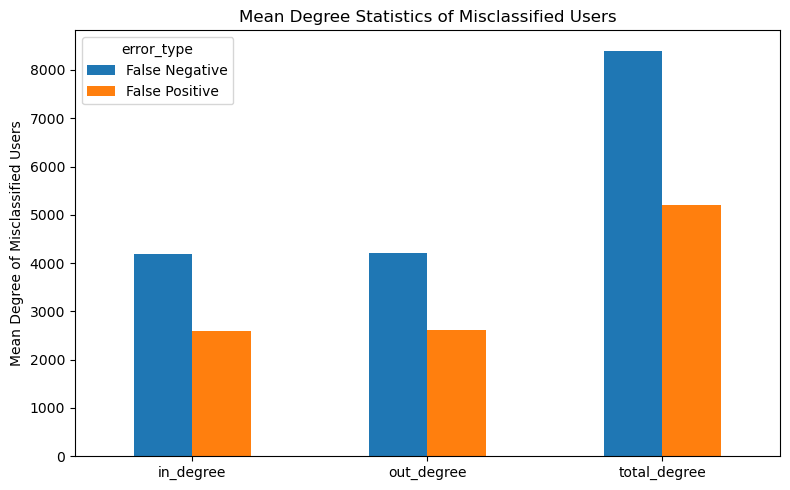

TOP RELATION-TYPE DEGREE DIFFERENCES (FP vs FN)


error_type,False Negative,False Positive,abs_diff
discuss_same_topic_total_degree,8361.04,5189.40,3171.64
mentions_total_degree,9.55,3.15,6.40
following_total_degree,18.71,14.66,4.05
retweets_total_degree,5.20,1.23,3.97
likes_total_degree,2.75,1.35,1.40
replies_to_total_degree,1.53,0.67,0.86
quotes_total_degree,1.11,0.26,0.85
member_of_communities_owned_by_total_degree,0.58,0.21,0.37
owner_of_communities_frequent_by_total_degree,0.31,0.06,0.25


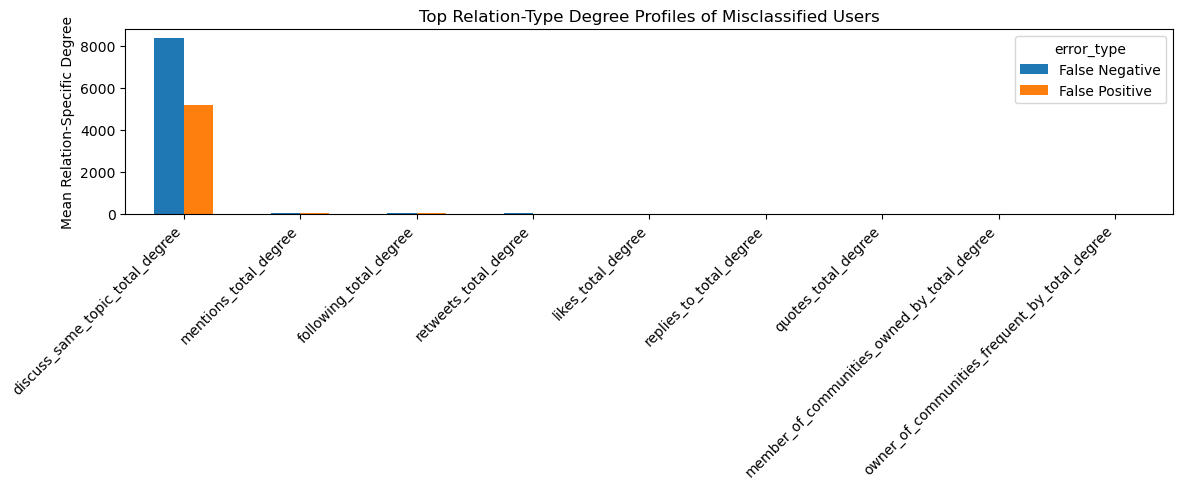

TOP 15 OVERCONFIDENT MISCLASSIFIED USERS WITH GRAPH STATS


,user_id,error_type,y_true,y_pred,y_prob_bot,confidence,in_degree,out_degree,total_degree
544,u937467860,False Negative,1,0,0.000500,0.999500,490,418,908
5,u38669987,False Negative,1,0,0.001379,0.998621,7941,8131,16072
805,u19536280,False Negative,1,0,0.001540,0.998460,5921,5875,11796
27,u2603132052,False Negative,1,0,0.001916,0.998084,5540,5695,11235
3540,u1094550761135108096,False Positive,0,1,0.998068,0.998068,2843,2843,5686
1444,u52163498,False Negative,1,0,0.001963,0.998037,5637,5631,11268
3040,u510358755,False Negative,1,0,0.002106,0.997894,1074,1071,2145
367,u28649627,False Negative,1,0,0.002140,0.997860,6983,7160,14143
3258,u48611134,False Negative,1,0,0.002233,0.997767,7347,7348,14695
2150,u82056281,False Negative,1,0,0.004839,0.995161,1399,1398,2797


In [ ]:
edge_index_cpu = data.edge_index.cpu()
edge_type_cpu = data.edge_type.cpu().numpy()

src = edge_index_cpu[0].numpy()
dst = edge_index_cpu[1].numpy()

num_nodes = data.num_nodes
idx_to_relation = {v: k for k, v in relation_to_idx.items()}

out_degree = np.bincount(src, minlength=num_nodes)
in_degree = np.bincount(dst, minlength=num_nodes)
total_degree = out_degree + in_degree

relation_degree_dict = {}
for rel_idx, rel_name in idx_to_relation.items():
    mask = edge_type_cpu == rel_idx
    src_rel = src[mask]
    dst_rel = dst[mask]

    out_rel = np.bincount(src_rel, minlength=num_nodes)
    in_rel = np.bincount(dst_rel, minlength=num_nodes)

    relation_degree_dict[f"{rel_name}_out_degree"] = out_rel
    relation_degree_dict[f"{rel_name}_in_degree"] = in_rel
    relation_degree_dict[f"{rel_name}_total_degree"] = out_rel + in_rel

df_eval_graph = df_eval.copy()

df_eval_graph["in_degree"] = in_degree[df_eval_graph["node_idx"].values]
df_eval_graph["out_degree"] = out_degree[df_eval_graph["node_idx"].values]
df_eval_graph["total_degree"] = total_degree[df_eval_graph["node_idx"].values]

for col_name, arr in relation_degree_dict.items():
    df_eval_graph[col_name] = arr[df_eval_graph["node_idx"].values]

df_errors_graph = df_eval_graph[df_eval_graph["error"]].copy()

basic_graph_cols = ["in_degree", "out_degree", "total_degree"]

print("=" * 70)
print("GRAPH PROFILE SUMMARY FOR MISCLASSIFIED USERS")
print("=" * 70)
display(
    df_errors_graph.groupby("error_type")[basic_graph_cols]
    .agg(["mean", "median", "min", "max", "count"])
    .round(2)
)

summary_basic = (
    df_errors_graph.groupby("error_type")[basic_graph_cols]
    .mean()
    .round(2)
)

summary_basic.T.plot(kind="bar", figsize=(8, 5))
plt.title("Mean Degree Statistics of Misclassified Users")
plt.ylabel("Mean Degree of Misclassified Users")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

relation_total_cols = [c for c in df_errors_graph.columns if c.endswith("_total_degree")]

relation_summary = (
    df_errors_graph.groupby("error_type")[relation_total_cols]
    .mean()
    .T
    .round(2)
)

if {"False Positive", "False Negative"}.issubset(relation_summary.columns):
    relation_summary["abs_diff"] = (
        relation_summary["False Positive"] - relation_summary["False Negative"]
    ).abs()
    relation_summary_top = relation_summary.sort_values("abs_diff", ascending=False).head(10)
else:
    relation_summary_top = relation_summary.head(10)

print("=" * 70)
print("TOP RELATION-TYPE DEGREE DIFFERENCES (FP vs FN)")
print("=" * 70)
display(relation_summary_top)

plot_cols = [c for c in relation_summary_top.columns if c != "abs_diff"]
relation_summary_top[plot_cols].plot(kind="bar", figsize=(12, 5))
plt.title("Top Relation-Type Degree Profiles of Misclassified Users")
plt.ylabel("Mean Relation-Specific Degree")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


print("=" * 70)
print("TOP 15 OVERCONFIDENT MISCLASSIFIED USERS WITH GRAPH STATS")
print("=" * 70)

cols_to_show = [
    "user_id", "error_type", "y_true", "y_pred", "y_prob_bot",
    "confidence", "in_degree", "out_degree", "total_degree"
]

display(
    df_errors_graph.sort_values("confidence", ascending=False)[cols_to_show].head(15)
)

In [51]:
best_ep = int(np.argmin(history["val_loss"])) + 1
print(f"val loss min at epoch {best_ep}: {min(history['val_loss']):.4f}")
print(f"val loss at final epoch:        {history['val_loss'][-1]:.4f}")
print(f"overfitting gap:                {history['val_loss'][-1] - min(history['val_loss']):.4f}")
print(f"best val F1:                    {max(history['val_f1']):.4f}")

val loss min at epoch 16: 0.2808
val loss at final epoch:        0.3094
overfitting gap:                0.0286
best val F1:                    0.8680


In [52]:
zero_rows = int((node_features_tensor[:, :-1].abs().sum(1) == 0).sum())
print(f"zero-feature nodes: {zero_rows:,} of {node_features_tensor.size(0):,}")

zero-feature nodes: 11,967 of 51,967
